In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nbformat.v2 import nbformat_minor

In [2]:
data_train = pd.read_csv("../data/home-credit-default-risk/application_train.csv")
df = data_train.copy()

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [5]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

Великий дисбаланс класів


In [6]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=122)

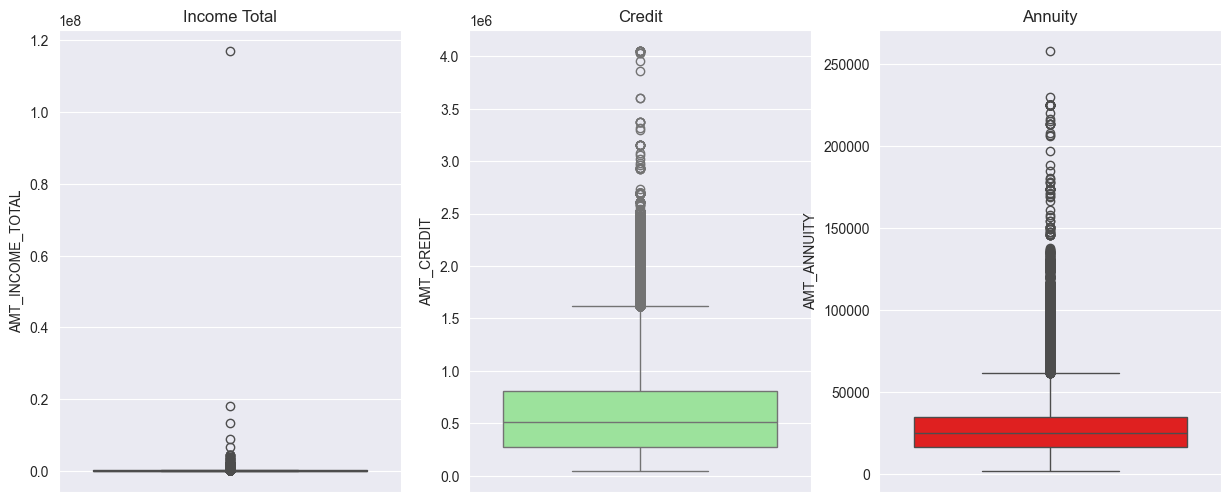

In [7]:
# Вибираємо тільки 3 колонки, пов'язані з грошима
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

sns.boxplot(y=df['AMT_INCOME_TOTAL'], ax=axes[0], color='blue')
axes[0].set_title('Income Total')

sns.boxplot(y=df['AMT_CREDIT'], ax=axes[1], color='lightgreen')
axes[1].set_title('Credit')

sns.boxplot(y=df['AMT_ANNUITY'], ax=axes[2], color='red')
axes[2].set_title('Annuity')

plt.show()

Є великі викиди, але ми їх не будемо видаляти, чи використовувати Scaling. Натомість використаємо Дерева.

In [8]:
miss_data = df.isna().sum()
miss_data[miss_data > 0]

AMT_ANNUITY                       12
AMT_GOODS_PRICE                  278
NAME_TYPE_SUITE                 1292
OWN_CAR_AGE                   202929
OCCUPATION_TYPE                96391
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY      41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
AMT_REQ_CREDIT_BUREAU_YEAR     41519
Length: 67, dtype: int64

In [9]:
miss_data_pct = (df.isna().sum() / len(df)) * 100
miss_data_pct = miss_data_pct[miss_data_pct > 0].sort_values(ascending=True)

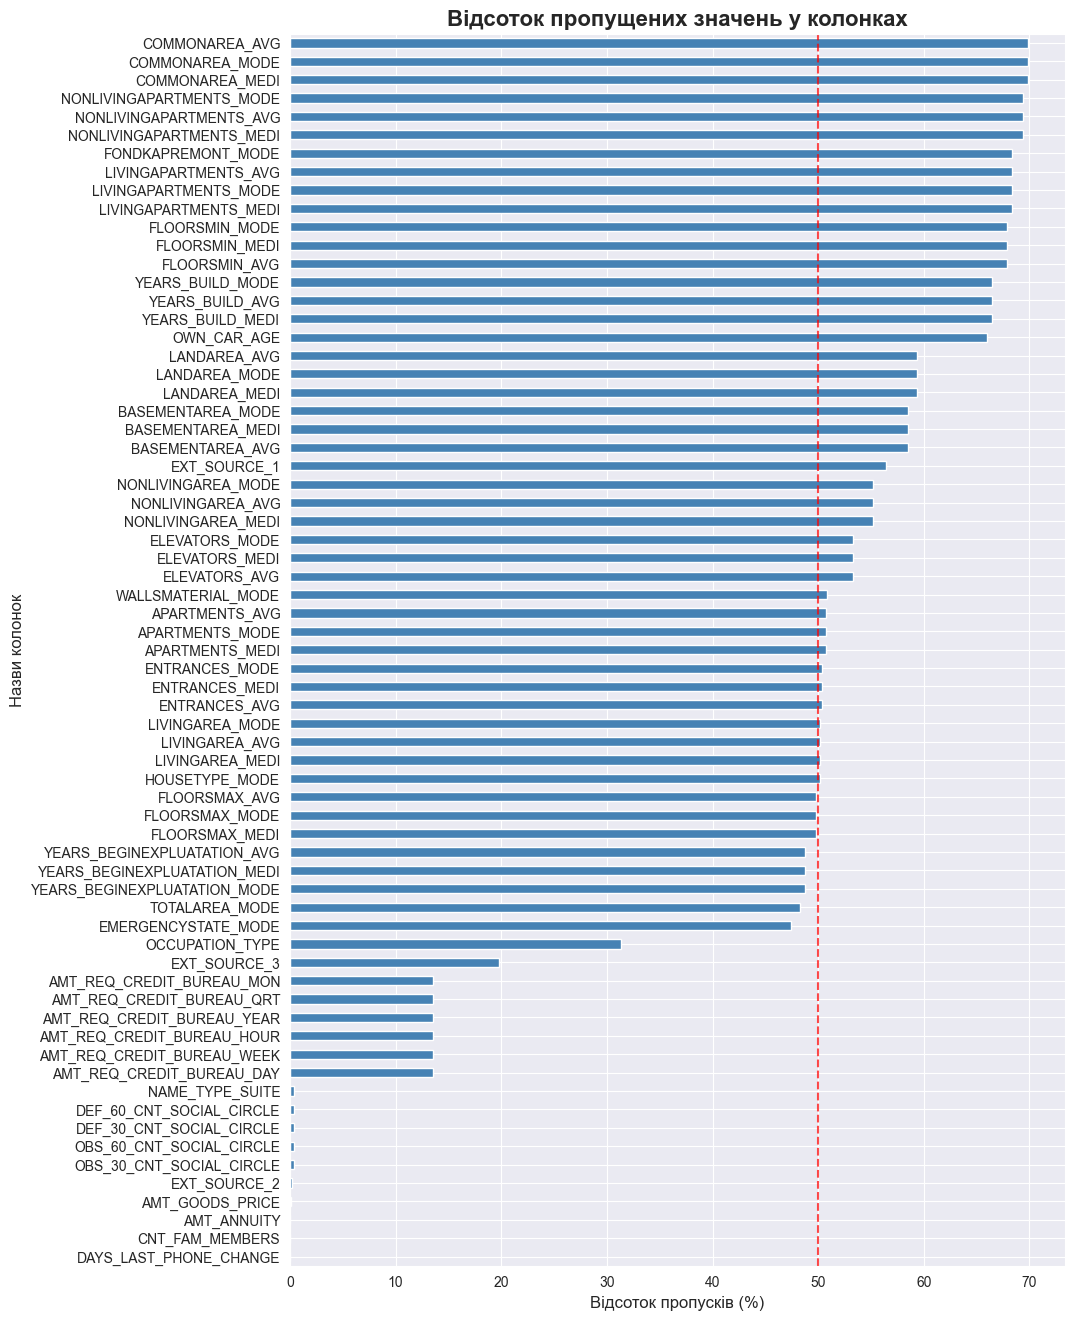

In [10]:
plt.figure(figsize=(10, 16))
miss_data_pct.plot(kind='barh', color='steelblue')

plt.title('Відсоток пропущених значень у колонках', fontsize=16, fontweight='bold')
plt.xlabel('Відсоток пропусків (%)', fontsize=12)
plt.ylabel('Назви колонок', fontsize=12)

plt.axvline(x=50, color='red', linestyle='--', alpha=0.7)
plt.show()

In [11]:
print(df['COMMONAREA_AVG'].isna().sum())
print(df.shape)

214865
(307511, 122)


Доволі багато пропущених даних, ми можемо побудувати максимально просту модель CatBoost, а вже потім дивитись на результати та покращувати наші табличні дані.


In [12]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, recall_score, precision_score, f1_score

In [13]:
df.head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
X = df.drop(['SK_ID_CURR', 'TARGET'], axis=1)
y = df['TARGET']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=200,
)
categorical_cols = X_train.select_dtypes(include=['object', 'str']).columns.tolist()
X_train[categorical_cols] = X_train[categorical_cols].fillna('Unknown')
X_test[categorical_cols] = X_test[categorical_cols].fillna('Unknown')
model.fit(X_train, y_train,cat_features=categorical_cols,
          eval_set=(X_test, y_test),
          early_stopping_rounds=100)
prediction = model.predict(X_test)

0:	test: 0.5553748	best: 0.5553748 (0)	total: 419ms	remaining: 6m 58s
200:	test: 0.7356364	best: 0.7356364 (200)	total: 1m 8s	remaining: 4m 31s
400:	test: 0.7464787	best: 0.7464787 (400)	total: 2m	remaining: 2m 59s
600:	test: 0.7506996	best: 0.7506996 (600)	total: 2m 52s	remaining: 1m 54s
800:	test: 0.7531196	best: 0.7531196 (800)	total: 3m 42s	remaining: 55.2s
999:	test: 0.7546383	best: 0.7546383 (999)	total: 4m 34s	remaining: 0us

bestTest = 0.7546382659
bestIteration = 999



In [17]:
roc_auc_score(y_test, prediction)

0.5036837978165561

In [19]:
probabilities = model.predict_proba(X_test)[:, 1]

correct_auc = roc_auc_score(y_test, probabilities)
print(correct_auc)

0.7546382658586692


Зробили базову модель і отримали непоганий результат 0.755